In [25]:
"""
Name: Module 7 Partition Data Recursively.py
Course: Data Preparation and Analysis
Created Date: September 30, 2023
Author: Ming-Long Lam, Ph.D.g
Organization: Illinois Institute of Technology
"""

'\nName: Module 7 Partition Data Recursively.py\nCourse: Data Preparation and Analysis\nCreated Date: September 30, 2023\nAuthor: Ming-Long Lam, Ph.D.g\nOrganization: Illinois Institute of Technology\n'

In [26]:
import matplotlib.pyplot as plt
import numpy
import pandas
import sys

In [27]:
from sklearn import tree

In [28]:
# Set some options for printing all the columns
numpy.set_printoptions(precision = 10, threshold = sys.maxsize)
numpy.set_printoptions(linewidth = numpy.inf)

In [29]:
pandas.set_option('display.max_columns', None)
pandas.set_option('display.expand_frame_repr', False)
pandas.set_option('max_colwidth', None)

In [30]:
pandas.options.display.float_format = '{:,.10f}'.format

In [31]:
inputData = pandas.read_excel(r'data\\Tiers.xlsx')

In [32]:
# inputData.sort_values(by="x").head(55)

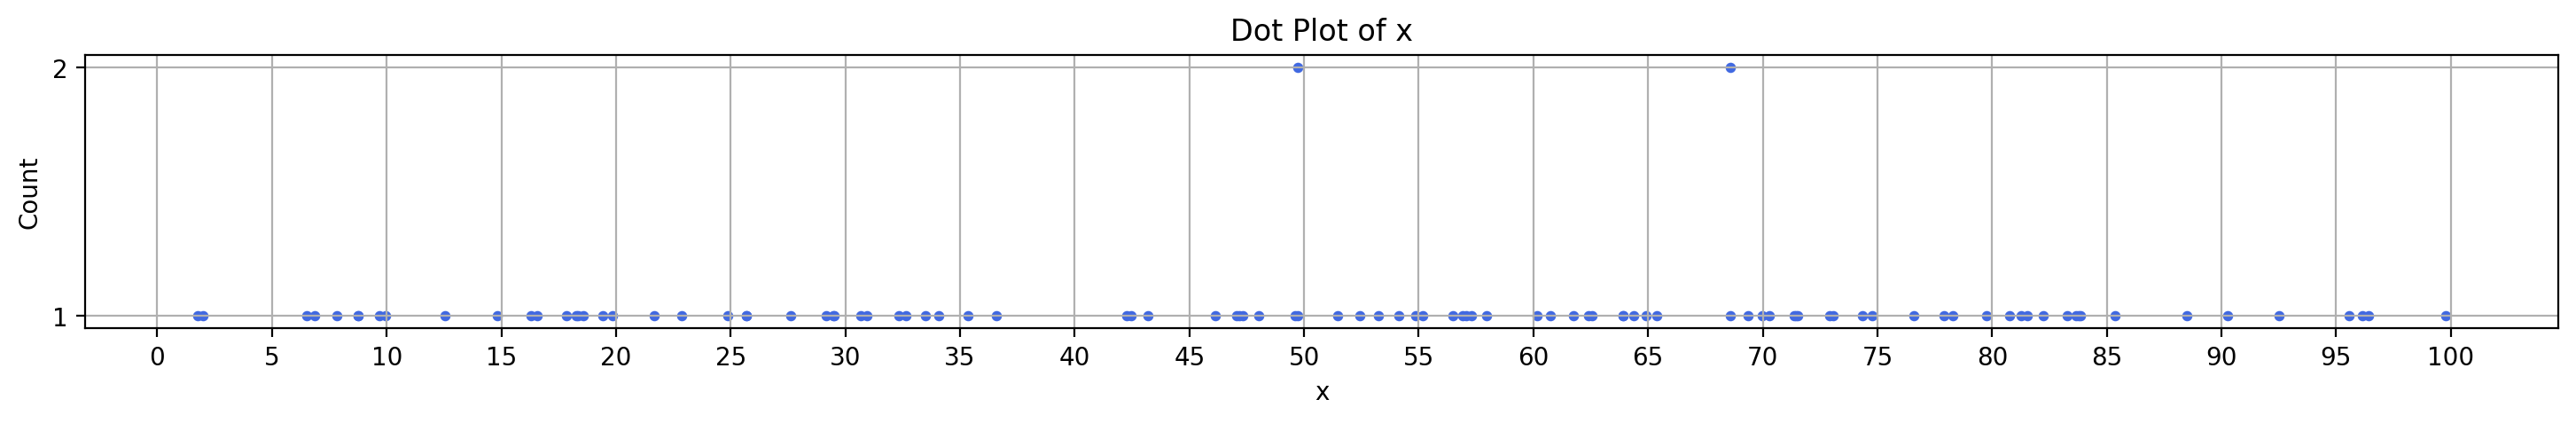

In [33]:
# Dot plot of x
unique, count = numpy.unique(inputData['x'], return_counts = True)
plt.figure(figsize = (18,2), dpi = 200)
for u, c in zip(unique, count):
   for y in range(1,(c+1),1):
      plt.scatter(u, y, c = 'royalblue', s = 10)
plt.xlabel('x')
plt.ylabel('Count')
plt.title('Dot Plot of x')
plt.xticks(range(0,105,5))
plt.yticks(range(0,max(count)+1,1))
plt.grid(axis = 'both')
plt.margins(x = 0.05, y = 0.05)
plt.show()

In [34]:
print('All Observations')
print(inputData['x'].describe())
print(inputData['y'].describe())

All Observations
count   100.0000000000
mean     50.6059000000
std      26.4697568647
min       1.7600000000
25%      28.7750000000
50%      53.6850000000
75%      71.4700000000
max      99.7900000000
Name: x, dtype: float64
count   100.0000000000
mean    728.0200000000
std     266.7472219238
min     300.0000000000
25%     305.0000000000
50%     888.0000000000
75%     900.0000000000
max     900.0000000000
Name: y, dtype: float64


In [35]:
# Calculate the Mean Squared Error
mse_y = inputData['y'].var(ddof = 0)

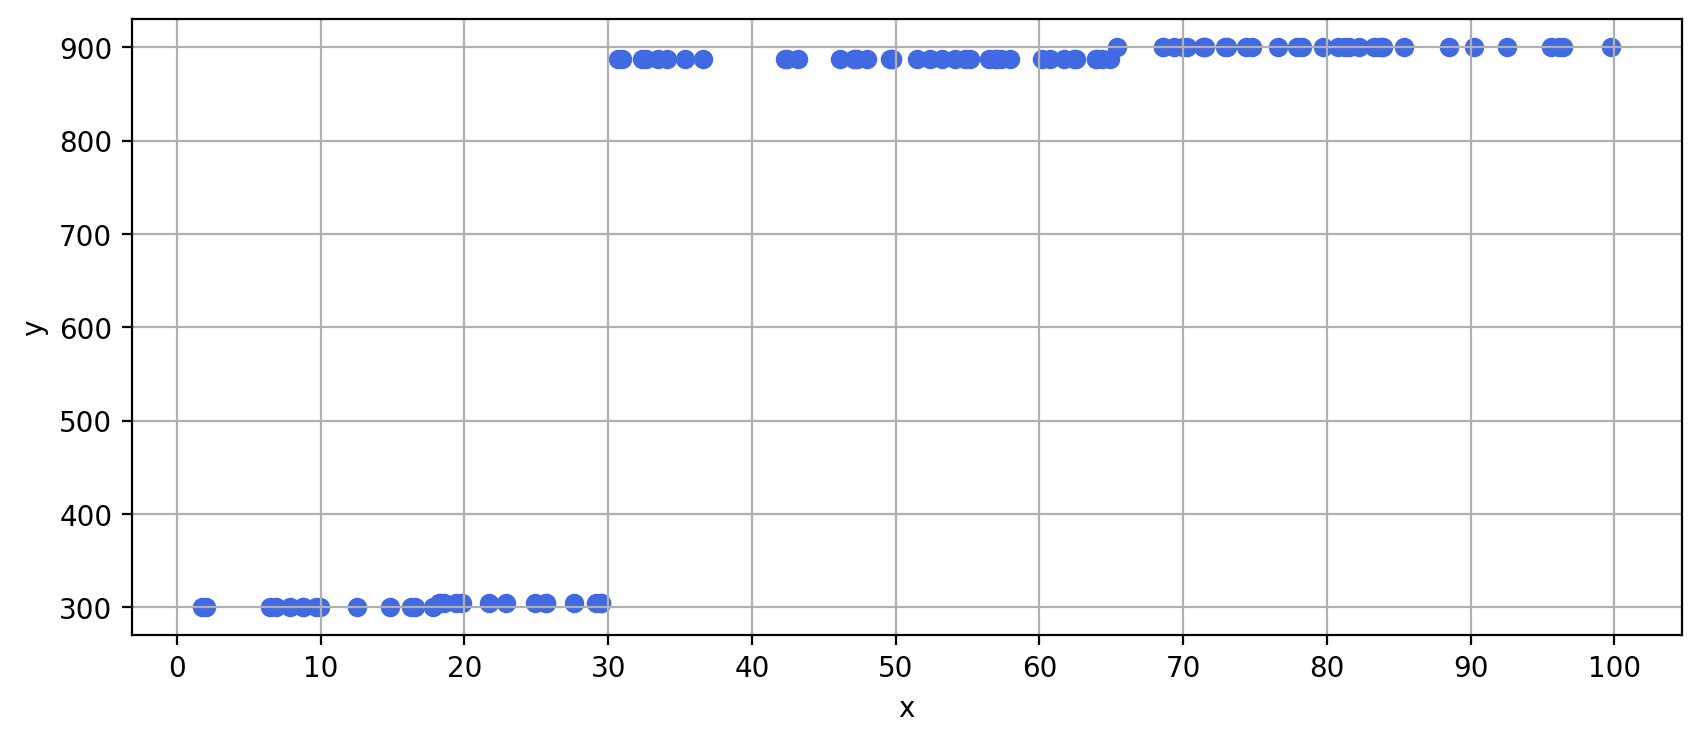

In [36]:
# Scatterplot of y with x
plt.figure(figsize = (10,4), dpi = 200)
plt.scatter(inputData['x'], inputData['y'], c = 'royalblue', marker = 'o')
plt.xlabel('x')
plt.ylabel('y')
plt.xticks(range(0,110,10))
plt.grid(axis = 'both')
plt.show()

In [37]:
# Define a function to calculate the sum of squared difference from mean
def ssdev_mean (u):
   u_diff = u - numpy.mean(u)
   return (numpy.dot(u_diff, u_diff))

In [38]:
# Define a function to determine the x value that optimally divide the input data
def find_optimal_split (inputDF):

   # What are the unique values of x?
   unique_x = inputDF['x'].value_counts(sort = False).sort_index()

   # Determine the optimal dividing line
   result_list = []
   for v in unique_x.index:
      ssdev = 0.0
      
      # Left subset
      subset = inputDF[inputDF['x'] <= v]
      if (subset.shape[0] > 0):
         ssdev += ssdev_mean(subset['y'])

      # Right subset
      subset = inputDF[inputDF['x'] > v]
      if (subset.shape[0] > 0):
         ssdev += ssdev_mean(subset['y'])

      result_list.append([v, ssdev])

   result_df = pandas.DataFrame(result_list, columns = ['Cutoff', 'SSDev'])

   iloc_x0 = result_df['SSDev'].argmin()
   x0 = result_df['Cutoff'].iloc[iloc_x0]
   SSDev0 = result_df['SSDev'].iloc[iloc_x0]

   return (x0, SSDev0, result_df)

In [39]:
# Calculate the overall sum of squared deviation from mean
SSDev_Overall = ssdev_mean(inputData['y'])

In [40]:
# Define a function to determine the x value that optimally divide the input data
x00, SSDev00, result_df = find_optimal_split (inputData)

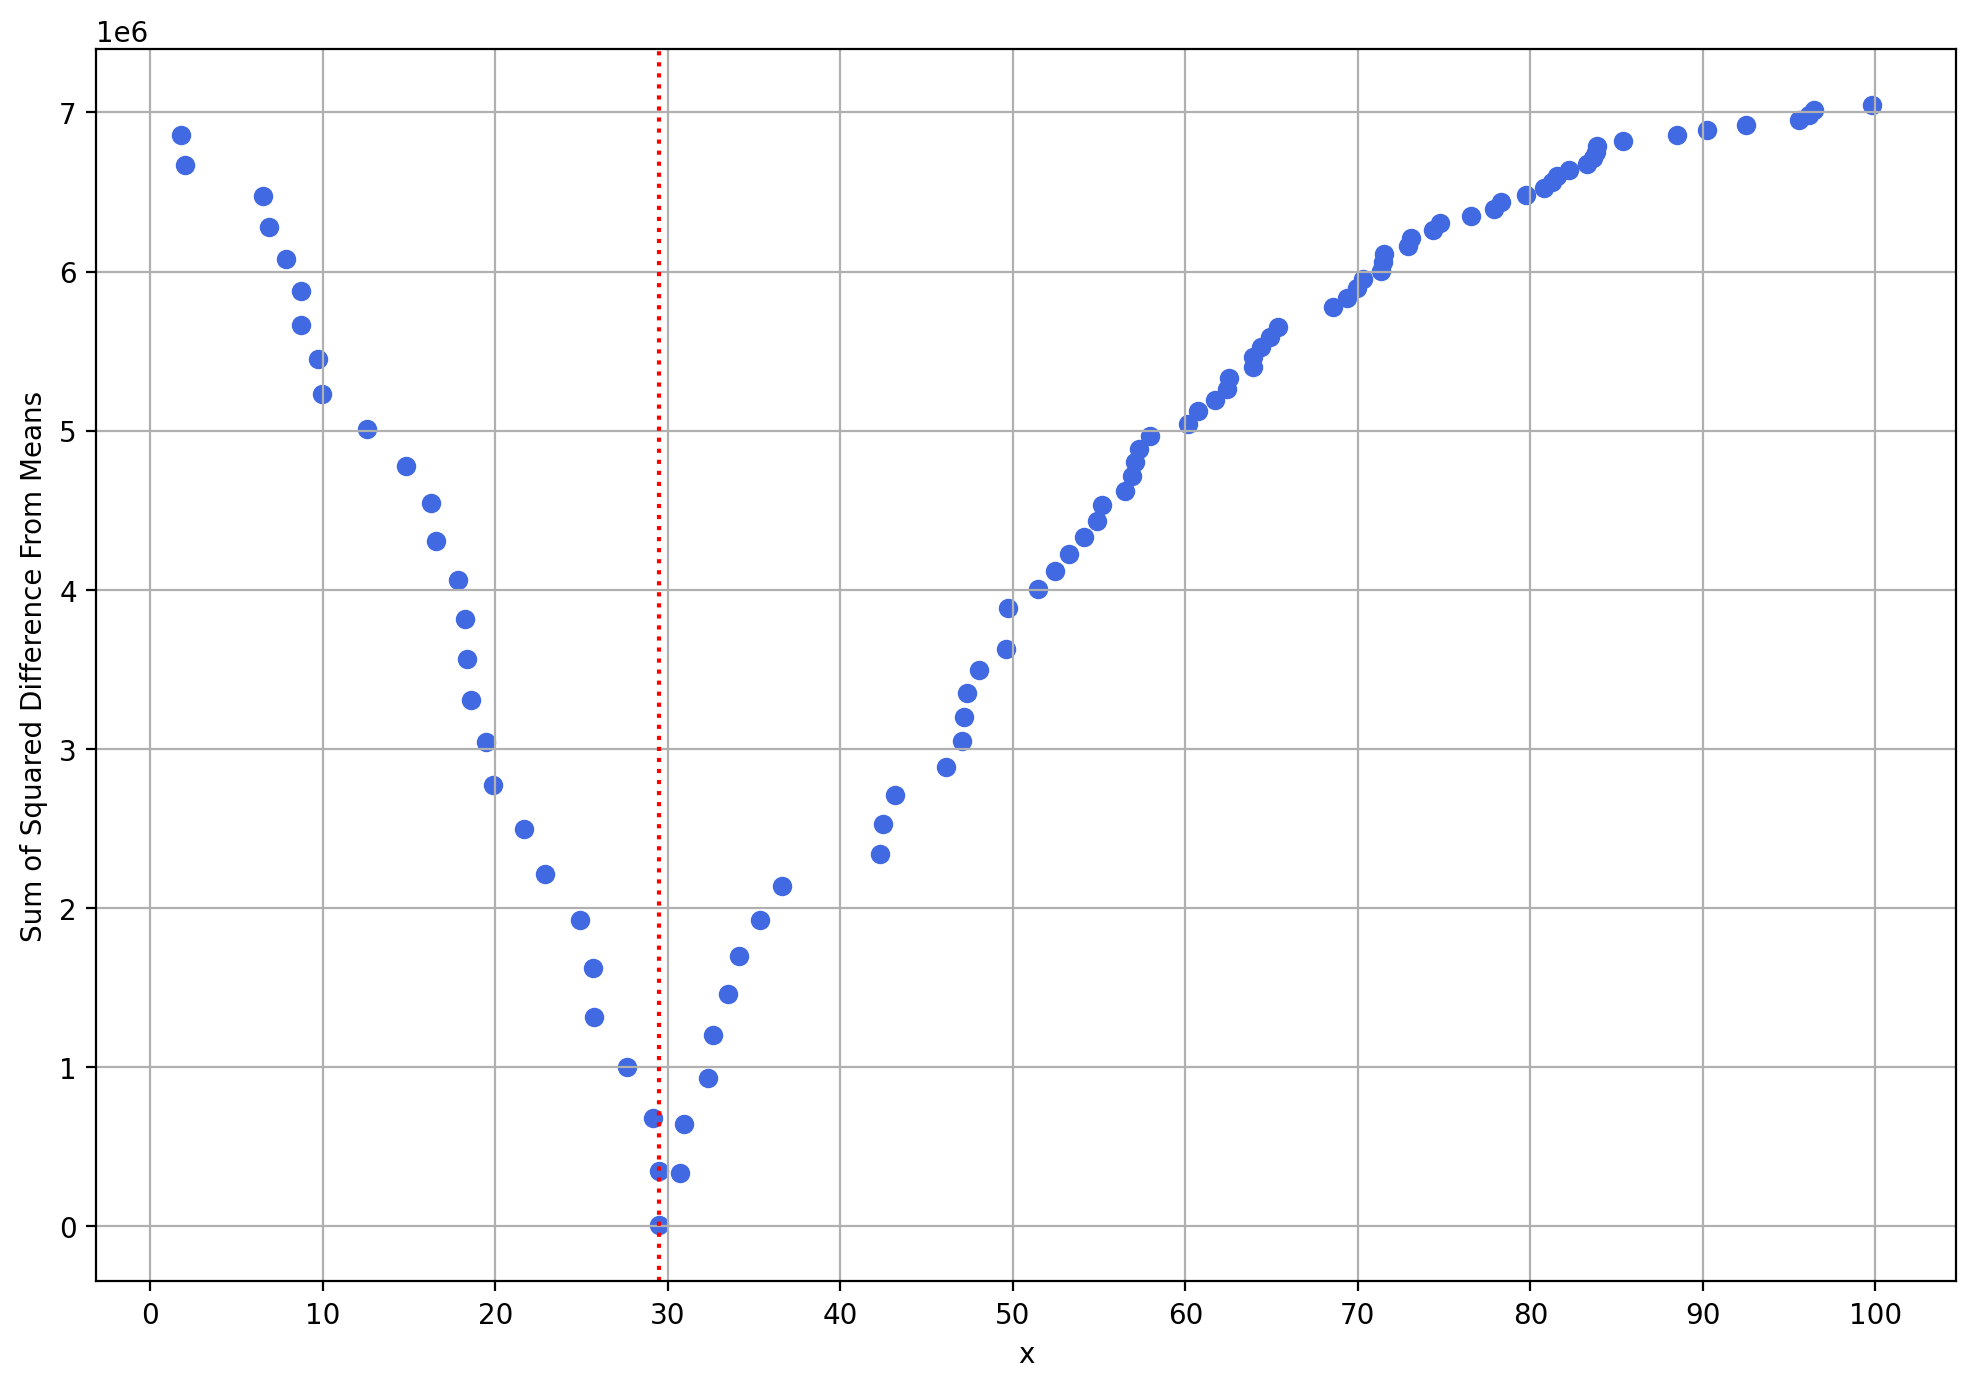

In [41]:
plt.figure(figsize = (12,8), dpi = 200)
plt.scatter(result_df['Cutoff'], result_df['SSDev'], c = 'royalblue', marker = 'o')
plt.xlabel('x')
plt.ylabel('Sum of Squared Difference From Means')
plt.xticks(range(0,110,10))
plt.axvline(x = x00, color = 'red', linestyle = 'dotted')
plt.grid(axis = 'both')
plt.show()

In [42]:
print('Left Segment')
print(inputData[inputData['x'] <= x00]['y'].describe())

Left Segment
count    28.0000000000
mean    302.5000000000
std       2.5458753861
min     300.0000000000
25%     300.0000000000
50%     302.5000000000
75%     305.0000000000
max     305.0000000000
Name: y, dtype: float64


In [43]:
print('Right Segment')
print(inputData[inputData['x'] > x00]['y'].describe())

Right Segment
count    72.0000000000
mean    893.5000000000
std       6.0210896960
min     888.0000000000
25%     888.0000000000
50%     888.0000000000
75%     900.0000000000
max     900.0000000000
Name: y, dtype: float64


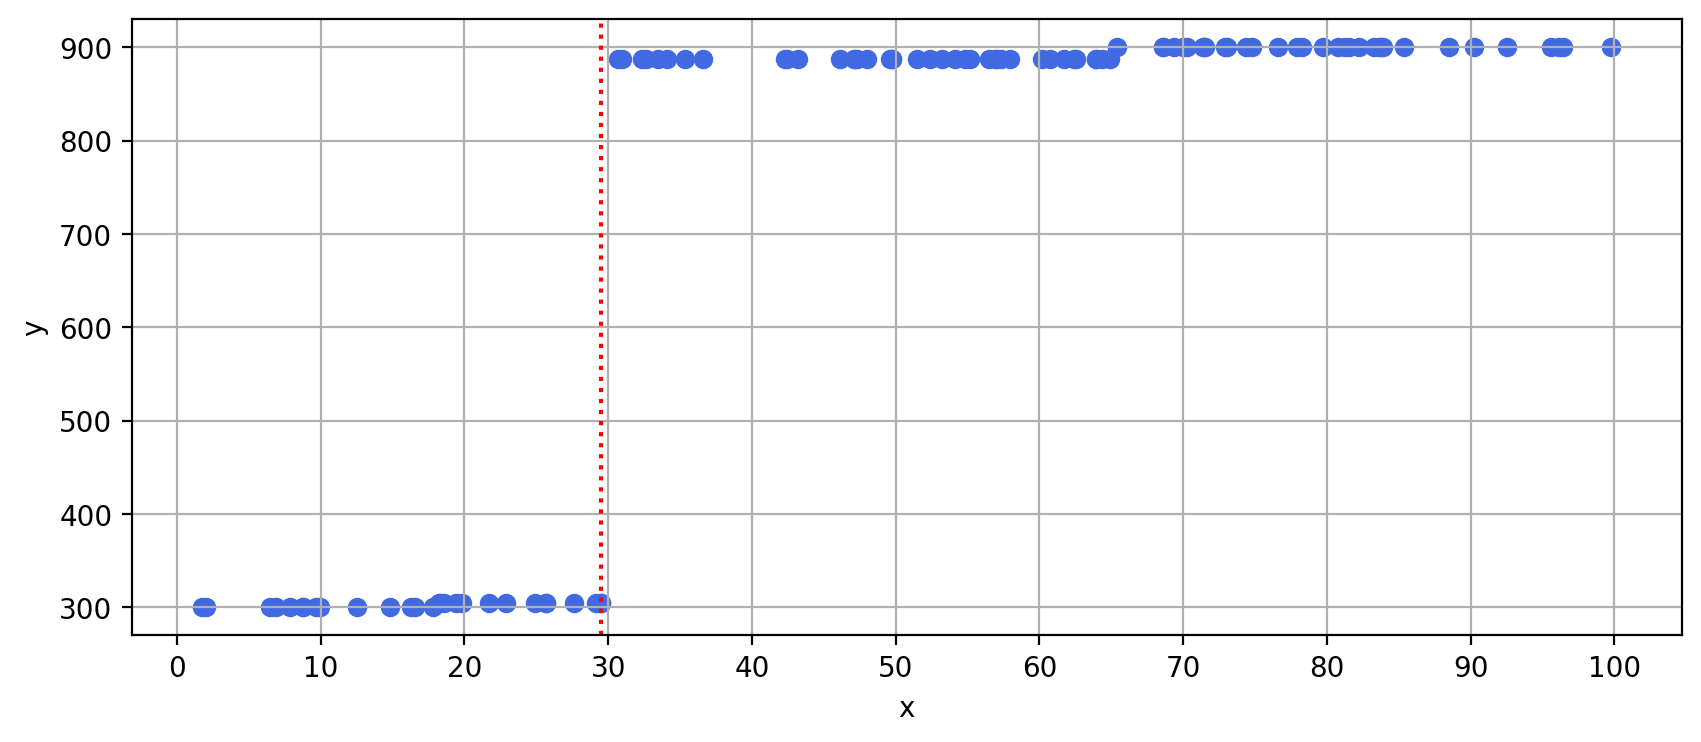

In [44]:
plt.figure(figsize = (10,4), dpi = 200)
plt.scatter(inputData['x'], inputData['y'], c = 'royalblue', marker = 'o')
plt.xlabel('x')
plt.ylabel('y')
plt.xticks(range(0,110,10))
plt.axvline(x = x00, color = 'red', linestyle = 'dotted')
plt.grid(axis = 'both')
plt.show()

In [45]:
# Put each segment into an individual dataframe
df_segment = inputData[inputData['x'] <= x00]

In [46]:
# Define a function to determine the x value that optimally divide the input data
x_10, SSDev10, result_df = find_optimal_split (df_segment)

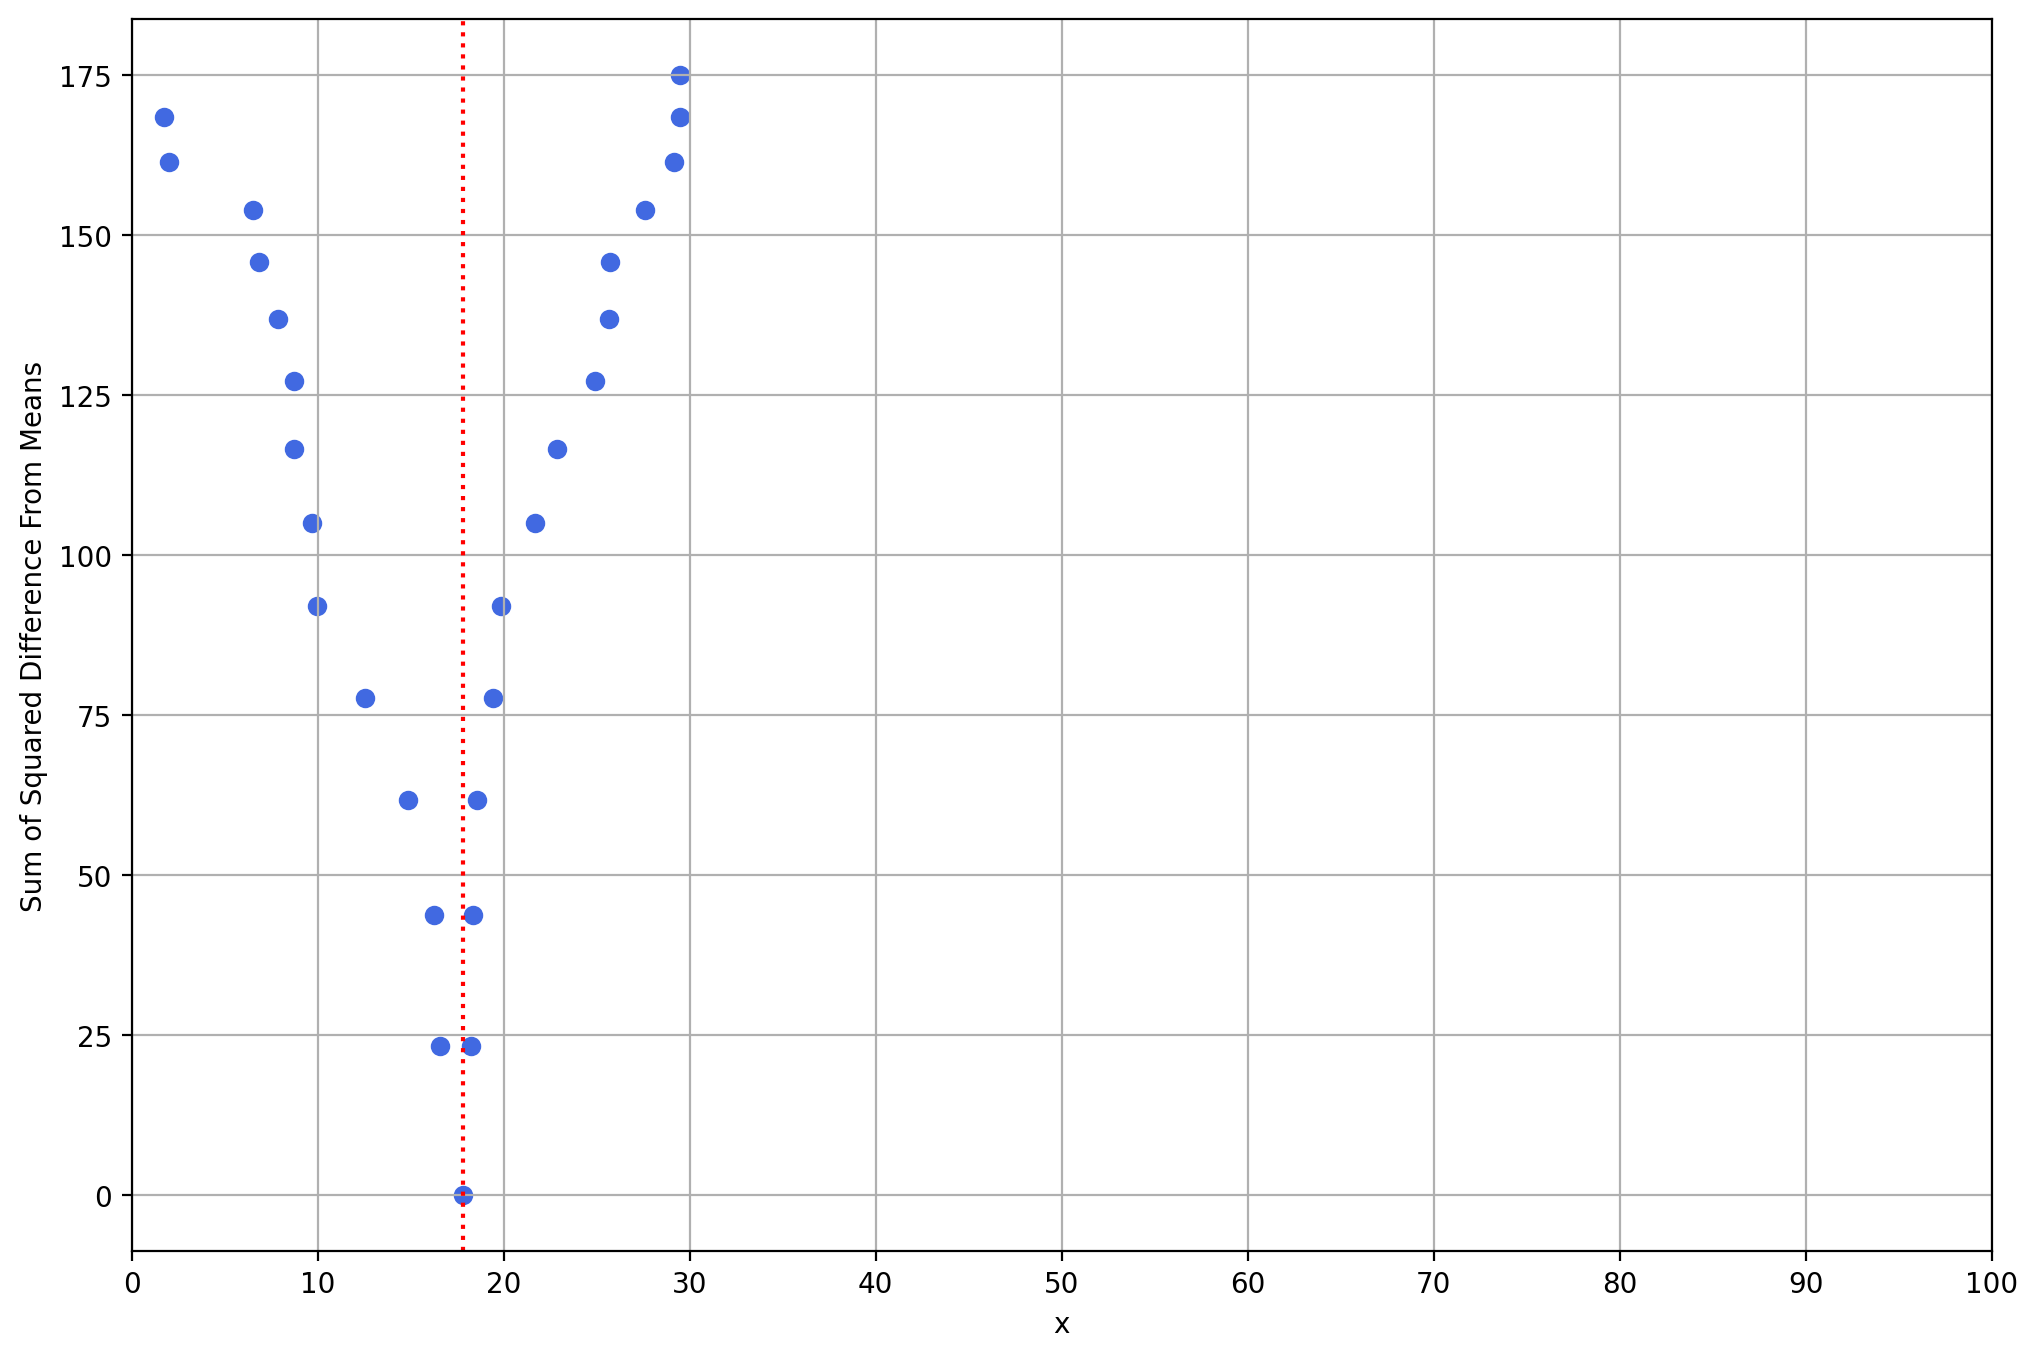

In [47]:
plt.figure(figsize = (12,8), dpi = 200)
plt.scatter(result_df['Cutoff'], result_df['SSDev'], c = 'royalblue', marker = 'o')
plt.xlabel('x')
plt.ylabel('Sum of Squared Difference From Means')
plt.xticks(range(0,110,10))
plt.axvline(x = x_10, color = 'red', linestyle = 'dotted')
plt.grid(axis = 'both')
plt.show()

In [48]:
# Put each segment into an individual dataframe
df_segment = inputData[inputData['x'] > x00]

In [49]:
# Define a function to determine the x value that optimally divide the input data
x_11, SSDev11, result_df = find_optimal_split (df_segment)

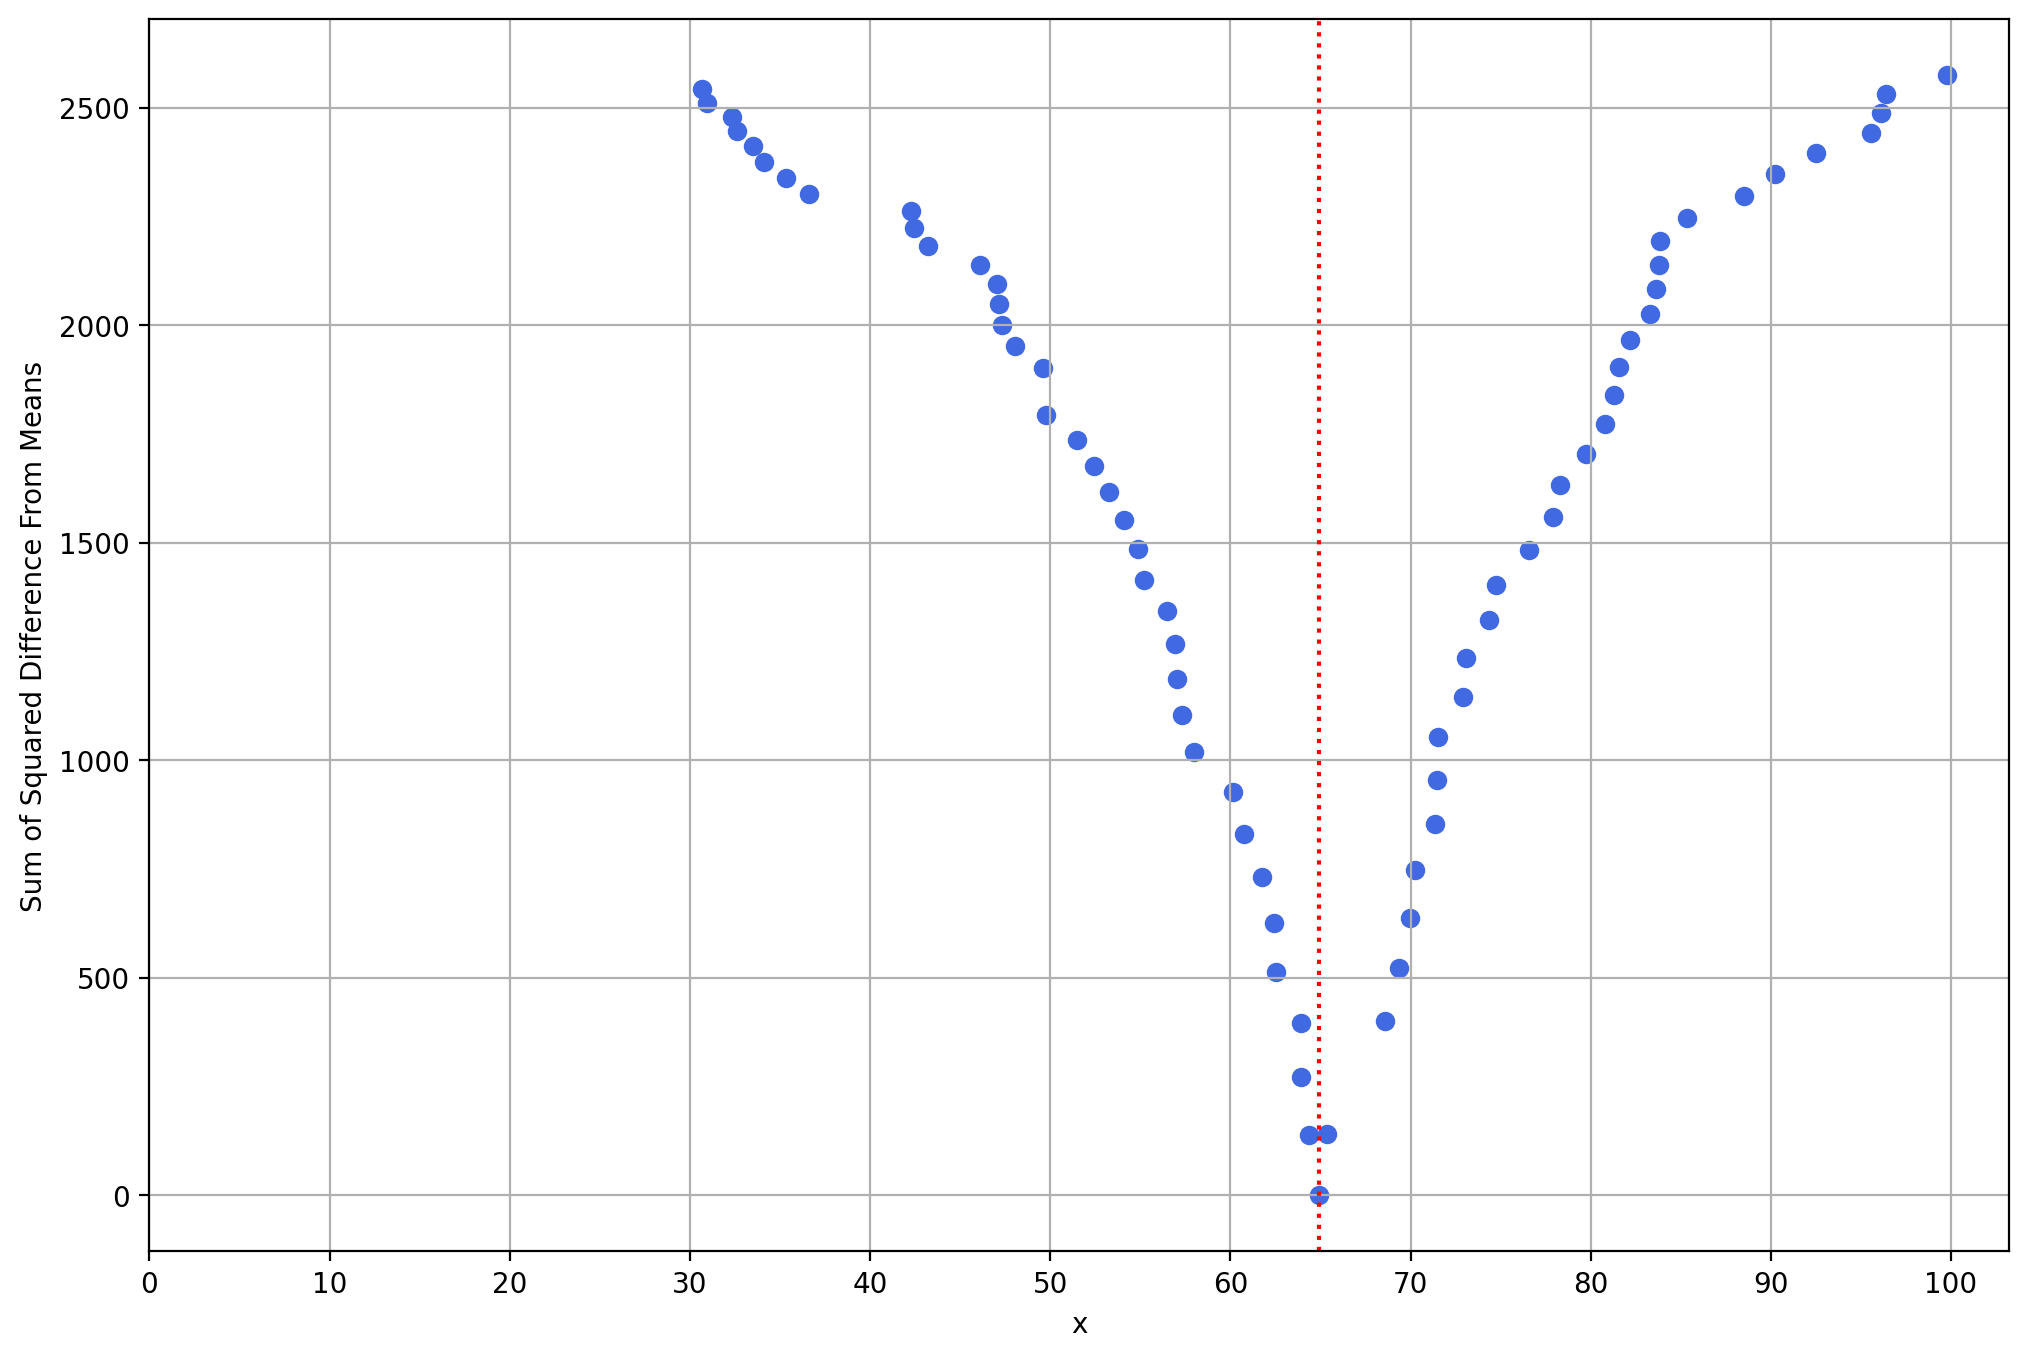

In [50]:
plt.figure(figsize = (12,8), dpi = 200)
plt.scatter(result_df['Cutoff'], result_df['SSDev'], c = 'royalblue', marker = 'o')
plt.xlabel('x')
plt.ylabel('Sum of Squared Difference From Means')
plt.xticks(range(0,110,10))
plt.axvline(x = x_11, color = 'red', linestyle = 'dotted')
plt.grid(axis = 'both')
plt.show()

Train a regression tree on y with x

In [51]:
regTree = tree.DecisionTreeRegressor(criterion = 'squared_error',
                                     max_depth = None, random_state = 2023484)
model = regTree.fit(inputData[['x']], inputData['y'])

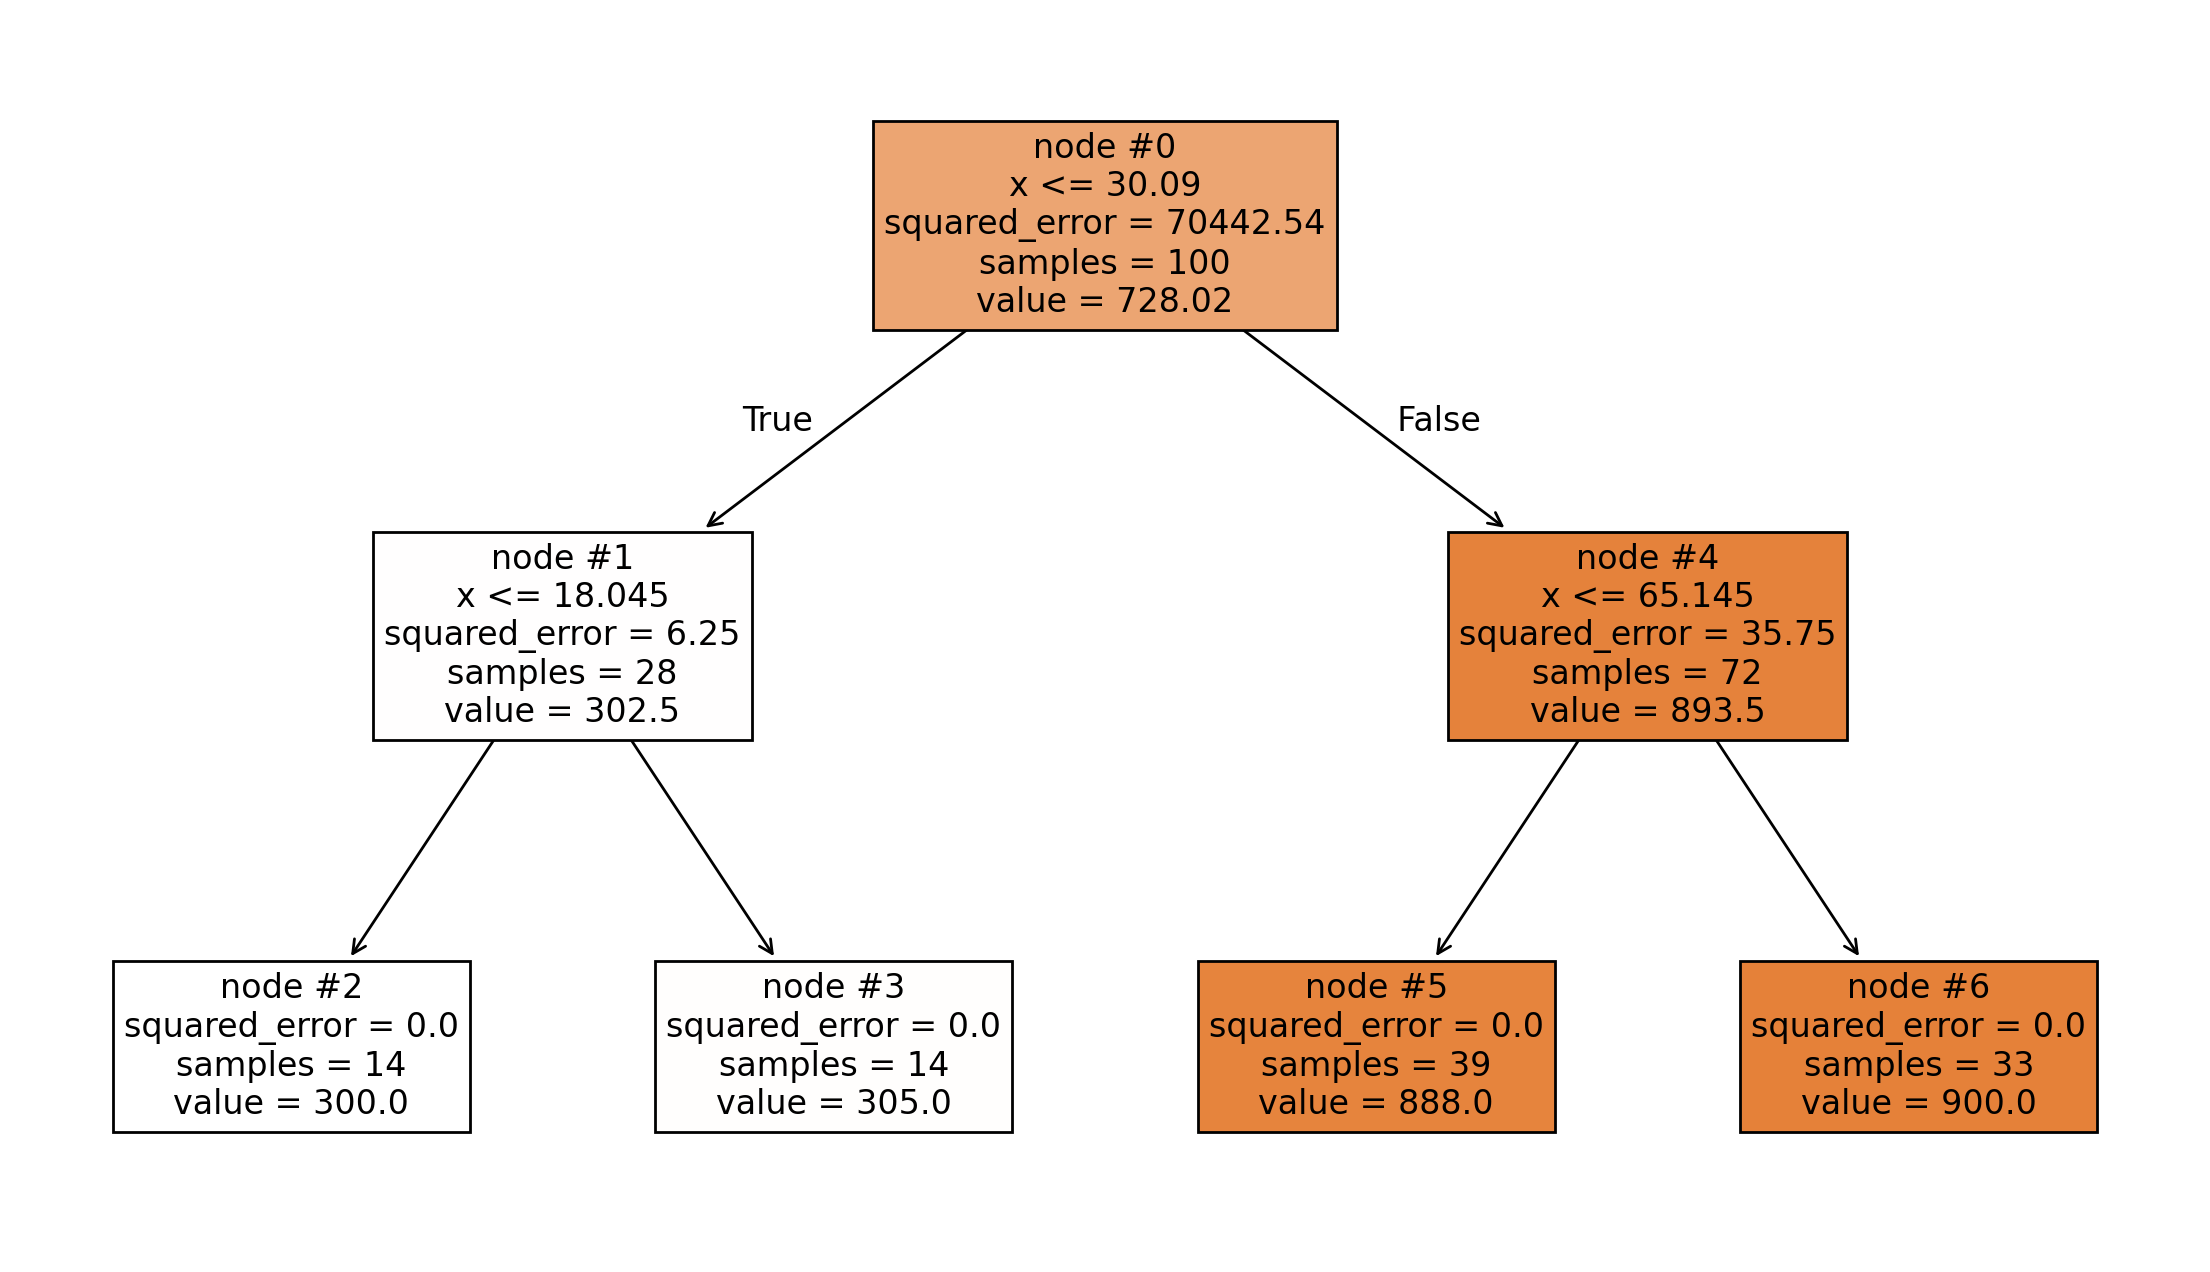

In [52]:
fig, ax = plt.subplots(1, 1, figsize = (14,8), dpi = 200)
tree.plot_tree(model, feature_names = ['x'], label = 'all',
               filled = True, impurity = True, node_ids = True,
               rounded = False, precision = 3, ax = ax, fontsize = 12)
plt.show()